<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Project2/Nikolai_Navarro_Project2_Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Project 2**
## **Nikolai Navarro**
## Spring 2026
---

## **Introduction**

Provide a brief description of:

- Dataset source  
- Population of interest  
- Data collection method (if known)  
- Limitations of the data  
- Possible bias or ethical concerns  

Include a citation for your dataset.

The dataset I am using was collected by the United States Department of Health and Human Services in 2014. It contains information from a random sample of 1000 births that occured in the U.S. with data such as the parents age, the babies weight, sex, and length of pregnancy. One limitation of the data is that it contains information from 1 decade ago but it will still be interesting to look at.

Citation: “US births” OpenIntro, United States Department of Health and Human Services, www.openintro.org/data/index.php?data=births14.

---
## **Data Overview**

Describe your dataset:

- Number of rows and columns  
- What each row represents  
- Table of variables:
  - Name  
  - Type (quantitative/categorical)  
  - Description  

Include any data cleaning or transformations performed.

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score

df = pd.read_csv("https://raw.githubusercontent.com/Nikolai-N484/Data201_NikolaiN/refs/heads/main/Project2/births14.csv")

df

,fage,mage,mature,weeks,premie,visits,gained,weight,lowbirthweight,sex,habit,marital,whitemom
0,34.0,34,younger mom,37,full term,14.0,28.0,6.96,not low,male,nonsmoker,married,white
1,36.0,31,younger mom,41,full term,12.0,41.0,8.86,not low,female,nonsmoker,married,white
2,37.0,36,mature mom,37,full term,10.0,28.0,7.51,not low,female,nonsmoker,married,not white
3,NaN,16,younger mom,38,full term,NaN,29.0,6.19,not low,male,nonsmoker,not married,white
4,32.0,31,younger mom,36,premie,12.0,48.0,6.75,not low,female,nonsmoker,married,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,28.0,24,younger mom,39,full term,NaN,20.0,6.49,not low,male,NaN,not married,not white
996,37.0,31,younger mom,38,full term,8.0,33.0,5.80,not low,female,nonsmoker,married,white
997,27.0,27,younger mom,34,premie,7.0,25.0,6.75,not low,female,nonsmoker,married,white
998,NaN,33,younger mom,42,full term,0.0,13.0,7.44,not low,male,nonsmoker,not married,white


In [187]:
columns = df.columns

shape = df.shape

print(columns)
print(shape)

Index(['fage', 'mage', 'mature', 'weeks', 'premie', 'visits', 'gained',
       'weight', 'lowbirthweight', 'sex', 'habit', 'marital', 'whitemom'],
      dtype='object')
(1000, 13)


In [188]:
count_nan = df.isna().sum()
print(count_nan)

fage              114
mage                0
mature              0
weeks               0
premie              0
visits             56
gained             42
weight              0
lowbirthweight      0
sex                 0
habit              19
marital             0
whitemom            0
dtype: int64


In [189]:
df = df.dropna()

count_nan2 = df.isna().sum()

print(count_nan2)

fage              0
mage              0
mature            0
weeks             0
premie            0
visits            0
gained            0
weight            0
lowbirthweight    0
sex               0
habit             0
marital           0
whitemom          0
dtype: int64


In [190]:
shape2 = df.shape

print(shape2)

(794, 13)


After filtering the data by dropping the data with NA's the data set has a total of 794 rows with 13 variables.

| Column | Description | Data Type |
|:-----|:------:|------:|
|  fage  |  Father's age in years.  |  Quantitative  |
|  mage  |  Mother's age in years.  |  Quantitative  |
|  mature  |  Maturity status of mother.  |  Categorical  |
|  weeks  |  Length of pregnancy in weeks.  |  Quantitative  |
|  premie  |  Whether the birth was classified as premature (premie) or full-term.  |  Categorical  |
|  visits  |  Number of hospital visits during pregnancy.  |  Quantitative  |
|  gained  |  Weight gained by mother during pregnancy in pounds.  |  Quantitative  |
|  weight  |  Weight of the baby at birth in pounds.  |  Quantitative  |
|  lowbirthweight  |  Whether baby was classified as low birthweight (low) or not (not low).  |  Categorical  |
|  sex  |  Sex of the baby, female or male.  |  Categorical  |
|  habit  |  Status of the mother as a nonsmoker or a smoker  |  Categorical  |
|  marital  |  Whether mother is married or not married at birth.  |  Categorical  |
|  whitemom  |  Whether mom is white or not white.  |  Categorical  |

---
## 4. **Data Analysis and Modeling**

### a. Data Exploration and Visualization

Create and interpret **at least 3 visualizations**, such as:

- Histograms  
- Scatter plots  
- Boxplots  
- Bar charts  

Describe **patterns, relationships, or interesting observations**.


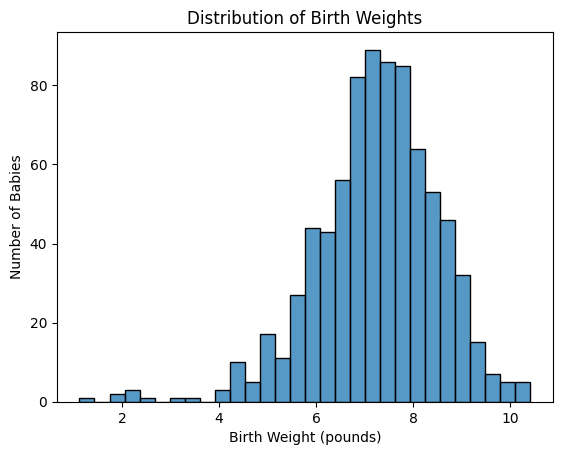

In [191]:
sns.histplot(df["weight"])
plt.xlabel("Birth Weight (pounds)")
plt.ylabel("Number of Babies")
plt.title("Distribution of Birth Weights")
plt.show()

In [192]:
df["weight"].describe()

,weight
count,794.000000
mean,7.247821
std,1.256358
min,1.120000
25%,6.560000
50%,7.335000
75%,8.007500
max,10.420000


This histogram is a normal distribution with a slight left skew. The data shows that most babies are born between 7 and 8 pounds. The baby with the highest weight was 10.4 pounds and the baby with the lightest was 1.1 pounds.

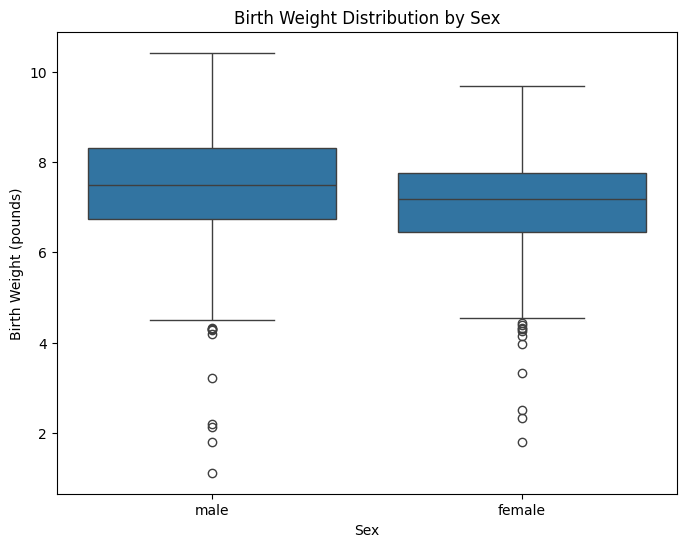

In [193]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="sex", y="weight", data=df)
plt.xlabel("Sex")
plt.ylabel("Birth Weight (pounds)")
plt.title("Birth Weight Distribution by Sex")
plt.show()

This boxplot shows the distribution of birth weights by sex. Males have a higher median weight around 7.5 pounds while females have a median around 7 pounds. Both boxplots seem to look normally distributed with each having some outliers with babies being under weight.

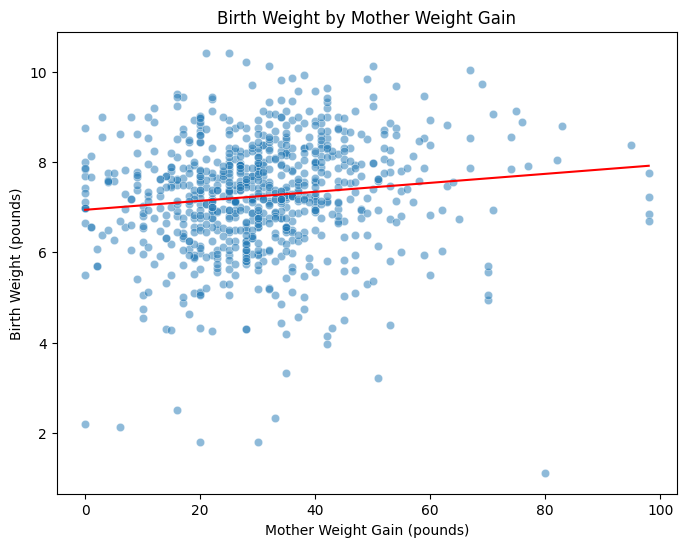

In [194]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="gained", y="weight", alpha=0.5, data=df)
plt.xlabel("Mother Weight Gain (pounds)")
plt.ylabel("Birth Weight (pounds)")

# Calculate the linear regression line
m, b = np.polyfit(df["gained"], df["weight"], 1)
x = np.array([df["gained"].min(), df["gained"].max()])
trend_line_y = m * x + b

plt.plot(x, trend_line_y, color="red")
plt.title("Birth Weight by Mother Weight Gain")
plt.show()

This scatterplot shows the distribution of birth weights by the weight gain of the mother during pregnancy. The trend line shows that there is a postivie correlation between the babies birth weights and the weight gain of the mother. However, the it is a very weak correlation as the data doesn't really gather around the trend line.

### b. Train/Test Split  

Split your data into:

- Training set  
- Testing set  

Explain your choice (e.g., 80/20 split).

In [195]:
df["weights"] = (df["weight"] > df["weight"].median()).astype(int)

X = df[["sex", "gained"]]
y = df["weights"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

/tmp/ipykernel_6183/2745891561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["weights"] = (df["weight"] > df["weight"].median()).astype(int)


### c. Build a Baseline Model  

Build a **linear regression model** using your selected variables.

Explain:

- What variables you included  
- Why you chose them

In [196]:
model = smf.logit(
    "weights ~ gained + C(sex)", data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.680861
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                weights   No. Observations:                  794
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            2
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.01772
Time:                        05:42:55   Log-Likelihood:                -540.60
converged:                       True   LL-Null:                       -550.36
Covariance Type:            nonrobust   LLR p-value:                 5.801e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.6598      0.178     -3.716      0.000      -1.008      -0.312
C(sex)[T.male]   

The variables I included were the sex of the baby and the weight gain of the mother during pregnancy. I chose these variables as the weight gain from the mother was shown to have a weak positive correlation with the birth weight of the baby while the sex of the baby was something I thought would be interesting to see the effect it had on the birth weight. Both variables have p-values less than 0.05 meaning they are both statistically significant. While holding the other varibales constant for every pound gained by the mother the birth weight increases by 0.014 pounds. While holding the other varibles constant male babies weighed 0.45 more pounds on average when compared to females.

### d. Improve Your Model  

Modify your model using at least **ONE** of the following:

- Transformation (log, polynomial, etc.)  
- Interaction term  
- Feature selection (adding/removing variables)  

You must:

- Explain **why** you made the change  
- Support your decision using:
  - plots  
  - patterns in the data  
  - model results

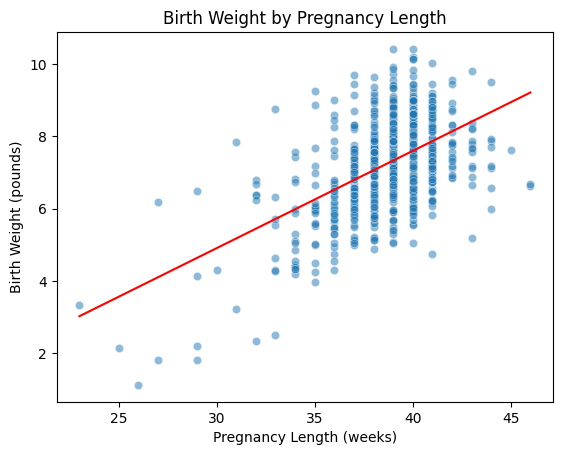

In [197]:
sns.scatterplot(x="weeks", y="weight", alpha=0.5, data=df)
plt.xlabel("Pregnancy Length (weeks)")
plt.ylabel("Birth Weight (pounds)")

m, b = np.polyfit(df["weeks"], df["weight"], 1)
x = np.array([df["weeks"].min(), df["weeks"].max()])
trend_line_y = m * x + b

plt.plot(x, trend_line_y, color="red")
plt.title("Birth Weight by Pregnancy Length")
plt.show()

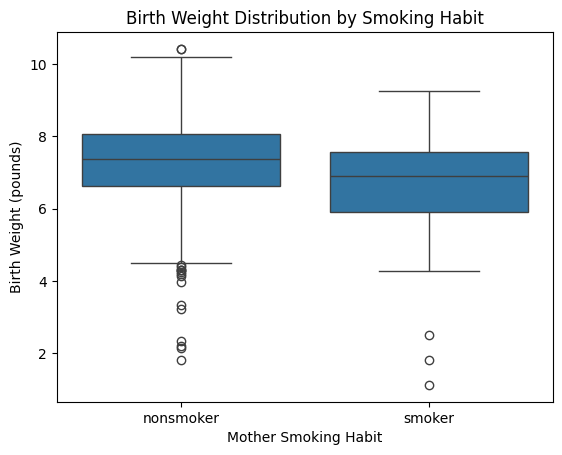

In [198]:
sns.boxplot(x="habit", y="weight", data=df)
plt.xlabel("Mother Smoking Habit")
plt.ylabel("Birth Weight (pounds)")
plt.title("Birth Weight Distribution by Smoking Habit")
plt.show()

In [199]:
model2 = smf.logit(
    "weights ~ gained + C(sex) + weeks + C(habit)", data=df
).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.629009
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                weights   No. Observations:                  794
Model:                          Logit   Df Residuals:                      789
Method:                           MLE   Df Model:                            4
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.09253
Time:                        05:42:56   Log-Likelihood:                -499.43
converged:                       True   LL-Null:                       -550.36
Covariance Type:            nonrobust   LLR p-value:                 3.969e-21
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -12.8049      1.612     -7.943      0.000     -15.965      -9.645
C(sex

I added in the length of the pregnancy and whether the mother was a smoker or not as varibles in the model. I had assumed that the smoking habits of the mother would have a significant influence on the babies weight as the boxplot showed that the babies median weight was lower for mother who were smokers but the p-value is greater than 0.05 so it isn't statistically significant which is suprising to see. As for the length of pregnancy the scatter plot showed a positive correlation between the length of pregnancy and the weight of the baby meaning that the longer the length is the more the baby weighs. This could be because the baby has more developmental time so the baby is able to gain more nutrients from the mother and gain more weight. The pregnancy length is statistically significant with an extremely small p-value. While holding other variable constant each week of the pregnancy increases the babies weight by 0.31 pounds.

### e. Compare Models  

Compare your baseline and improved models using appropriate metrics:

- RMSE  
- \(R^2\)

Clearly explain:

- Which model performs better  
- Why

In [200]:
# For the baseline model
y_true = df["weights"]
y_pred_baseline = model.predict(df)
model_rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
model_r2 = r2_score(y_true, y_pred_baseline)

# For the improved model
y_pred_improved = model2.predict(df)
model2_rmse = np.sqrt(mean_squared_error(y_true, y_pred_improved))
model2_r2 = r2_score(y_true, y_pred_improved)

print(f"Baseline Model RMSE: {model_rmse:.4f}")
print(f"Baseline Model R-squared: {model_r2:.4f}")
print(f"Improved Model RMSE: {model2_rmse:.4f}")
print(f"Improved Model R-squared: {model2_r2:.4f}")

Baseline Model RMSE: 0.4938
Baseline Model R-squared: 0.0245
Improved Model RMSE: 0.4680
Improved Model R-squared: 0.1240


The imporved model performs better than the original model. This is because the improved model has a lower RMSE of 0.4680 compared to the original models 0.4938 and a higher r-squared of 0.1240 compared to the original models 0.0245. The RMSE shows that the models predictions of birth weight is off by an average of 0.4680 which shows a good fit. The r-squared is 0.1240 which mean the model explains about 12.4% of the variation of birth weights. The improved model doesn't really explain much about the weight of babies but it is still better than the original.

### f. Interpret Your Final Model  

Explain your regression model in plain language:

- Which variables are important?  
- What do the coefficients mean?  
- How do predictors affect the response variable?

The sex of the baby, the length of the pregnancy, and the weight gain from the mom all d p-values less than 0.05 meaning they are all statistically significant. The smoking habits of the mother didn't had a p-value of 0.096 which is greater than 0.05 meaning it isn't statistically significant. While holding the other varibales constant for every pound gained by the mother the birth weight increases by 0.014 pounds. While holding the other varibles constant male babies weighed 0.537 more pounds on average when compared to females. While holding other variable constant each week of the pregnancy increases the babies weight by 0.313 pounds.

### g. Predictions  

Use your final model to:

- Make predictions for **3 new data points**  
- Interpret the results in context

In [201]:
new_data = pd.DataFrame({
    "gained": [30, 45, 25],
    "sex": ['male', 'female', 'female'],
    "weeks": [39, 40, 37],
    "habit": ['nonsmoker', 'smoker', 'nonsmoker']
})

predictions = model2.predict(new_data)

print("Predictions for new data points (probability of birth weight > median):")
for i, prob in enumerate(predictions):
    print(f"Data Point {i+1}: {prob:.4f}")

# Interpretation of results:
# If the probability is > 0.5, the model predicts the baby's weight is above the median.
# If the probability is <= 0.5, the model predicts the baby's weight is not above the median.


Predictions for new data points (probability of birth weight > median):
Data Point 1: 0.5892
Data Point 2: 0.4613
Data Point 3: 0.2949


---
## **Conclusions and Recommendations**

Summarize:

- Key findings  
- Model performance  
- Any challenges or limitations  
- Whether your model generalizes well  
- Possible next steps or improvements  

If results are not strong or interesting, explain why.